In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

import sys
sys.path.append("..")

from src.utils import *

## Dynamical Critical Exponent from $H_0$ Persistence of Normal Mode Time Series

One method of extracting the dynamical critical exponent (DCE) from the multi-species exclusion process is to apply topological data analysis directly to the hydrodynamic normal modes since we know from our previous experimentatoin that the hydrodynamic normal mode time series if effective in splitting the process into its different regimes. The function `normal_mode_height_time_series` returns a time series of these modes in the form

$$H(t,x,m)$$

where $t$ is time, $x$ is the spatial position, and $m$ labels the hydrodynamic mode. For a fixed mode $m$, each time slice gives a spatial height profile

$$h_m(t,x)$$

However at a certain time $t$ this is just a one dimensional data point with no topological features so we construct a topological observable from the shape of this profile. At each time $t$, the spatial profile is converted into a point cloud by taking local patches of length $w$. Each patch becomes one point:

$$\big(h_m(t,x), h_m(t,x+1), \ldots, h_m(t,x+w-1)\big)$$

Thus, a single height profile produces a point cloud in $\mathbb{R}^w$. This point cloud represents the collection of local spatial patterns appearing in the hydrodynamic mode at that time.

We then compute the total finite $H_0$ persistence of this point cloud. The $H_0$ persistence measures the connected-component structure of a point cloud as the filtration radius increases. Intuitively, it measures how separated or clustered the points are. If the patch cloud contains several well-separated groups, the $H_0$ persistence is larger. If the patch cloud is more tightly connected, the $H_0$ persistence is smaller. 

The key idea is that if the hydrodynamic mode relaxes slowly, then the topology of its patch cloud should also retain memory for a long time. Therefore, we compute the autocorrelation of the topological observable,

$$C_O(\Delta t) \langle O(t)O(t+\Delta t)\rangle_t$$

and extract a relaxation time $\tau_{\mathrm{TDA}}(L)$. This relaxation time can be defined as the first time the autocorrelation drops below $1/e$, or as the integrated autocorrelation time up to the first zero crossing.

In [2]:
L_values = np.arange(240, 600, 15)

rates_matrix = 1 - np.diag((1, 1, 1))
# rates_matrix = np.triu(np.ones((3, 3), dtype=np.float64), k=1)

mode_index = 0

n_samples = 6000
sample_every = 25

patch_divisor = 8
patch_stride = 1

N_runs = 4
tda_every = 2

taus = []

Note the following simulation may take upwards of $12 \frac 12$ hours to run on the Purdue Negishi supercomputers (I really wouldn't recommend running it again 🙃), below will outline how to submit the job on engines through slurm to speed up computation to around an hour for two modes (running on 24 CPUs).

In [3]:
for L in tqdm(L_values, smoothing=0):
    tau_runs = []

    for run_id in range(N_runs):
        process = MultiSpeciesExclusionProcess(dimension=3, density=[1/3, 1/3, 1/3], rates_matrix=rates_matrix, length=int(L))

        H = process.normal_mode_height_time_series(n_samples=n_samples, sample_every=sample_every)

        patch_window = max(8, int(L) // patch_divisor)

        n_times = H.shape[0]
        tda_indices = np.arange(0, n_times, tda_every)

        h0_series = np.zeros(len(tda_indices), dtype=float)

        for j, t in enumerate(tda_indices):
            h_profile = H[t, :, mode_index]
            points = patch_point_cloud(h_profile, window=patch_window, stride=patch_stride)
            h0_series[j] = h0_total_persistence(points)

        C = autocorrelation(h0_series)

        times = np.arange(len(C)) * sample_every * tda_every
        tau = relaxation_time(C, times)

        tau_runs.append(tau)

    tau_mean = np.nanmean(tau_runs)
    taus.append(tau_mean)

100%|██████████| 24/24 [12:34:03<00:00, 1885.16s/it]  


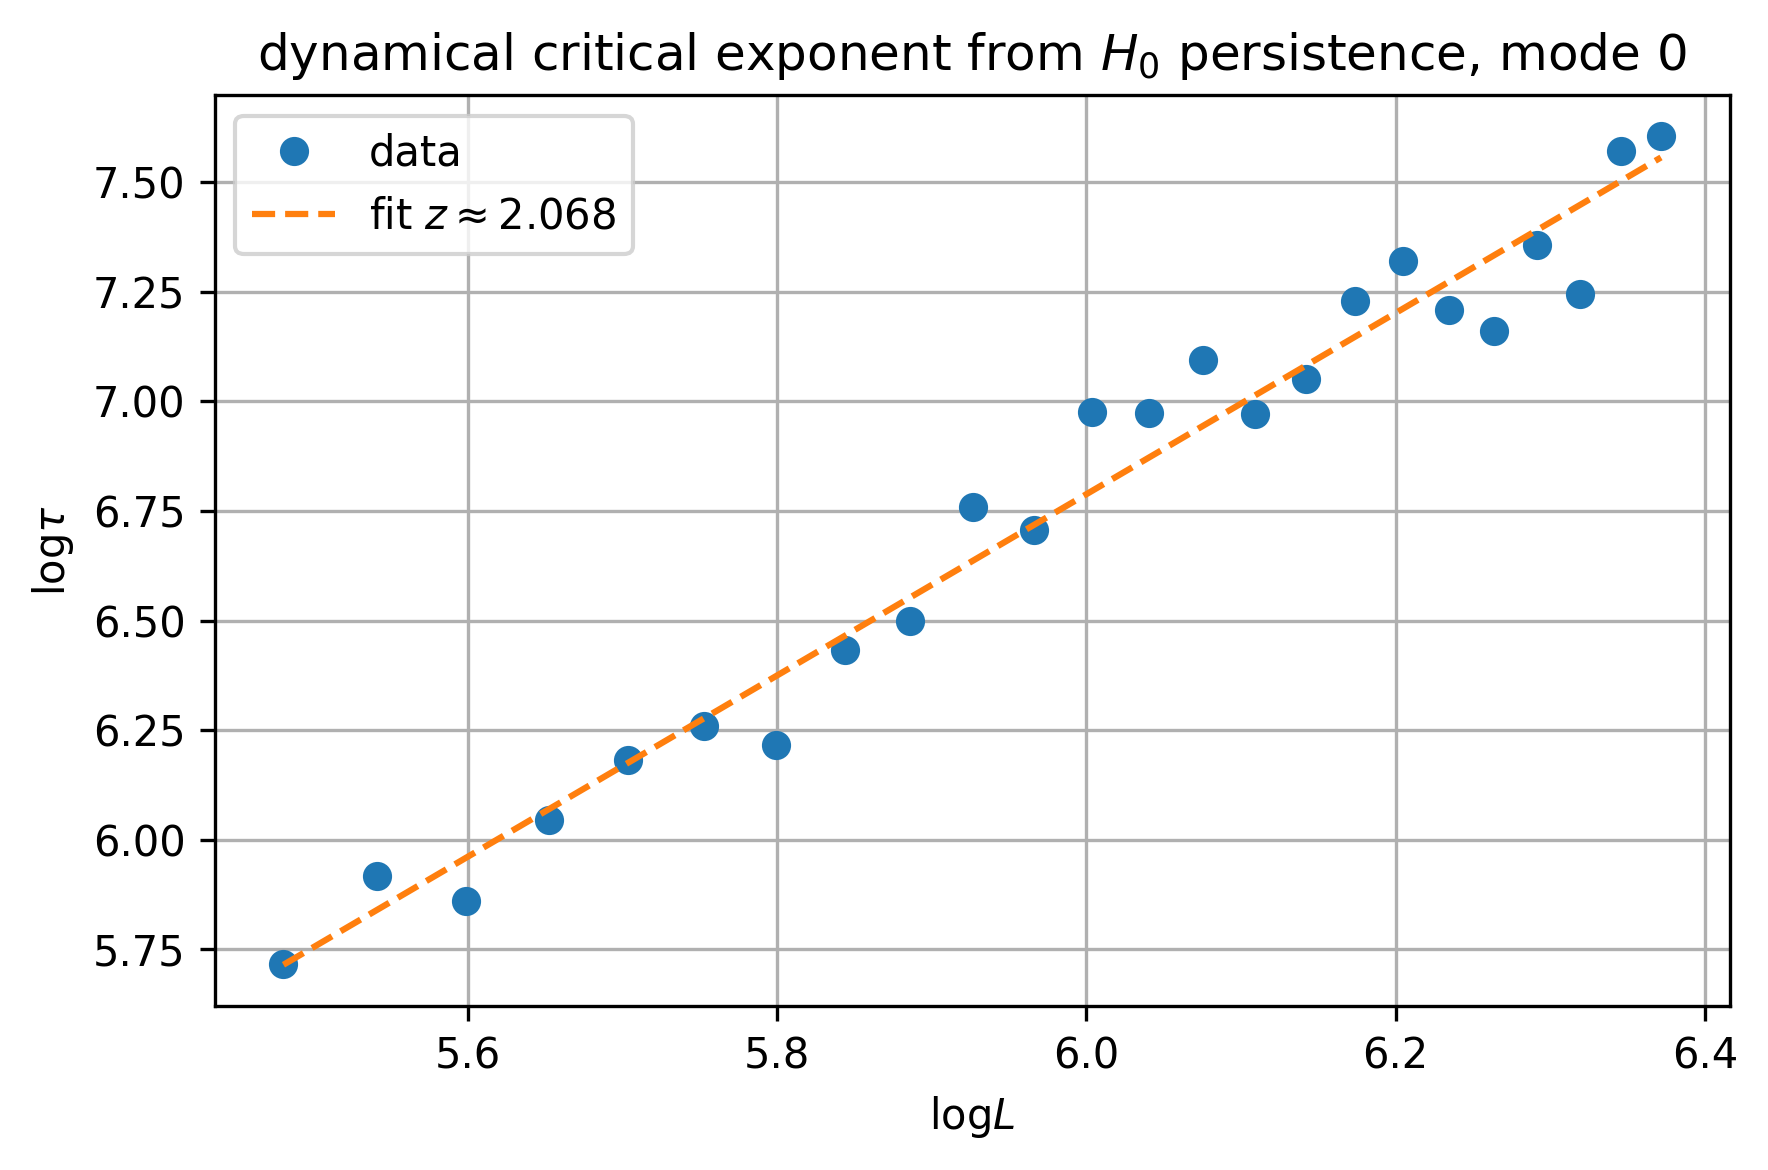

In [4]:
taus = np.array(taus)
valid = np.isfinite(taus) & (taus > 0)

logL = np.log(L_values[valid])
logtau = np.log(taus[valid])

z, intercept = np.polyfit(logL, logtau, 1)
fit = intercept + z * logL

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(logL, logtau, "o", label="data")
plt.plot(logL, fit, "--", label=fr"fit $z \approx {z:.3f}$")

plt.xlabel(r"$\log L$")
plt.ylabel(r"$\log \tau$")
plt.title(fr"dynamical critical exponent from $H_0$ persistence, mode {mode_index}")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## Using `ipyparallel` to Speed Up the TDA Computation

The $H_0$ persistence calculation is expensive because we repeat the same full procedure for many system sizes $L$: simulate the process, compute the normal-mode height time series, build patch point clouds, compute $H_0$ persistence, compute the autocorrelation, and extract a relaxation time. 

Each value of $L$ is independent of the others, so this is an ideal place to use parallel computing. With `ipyparallel`, we start an IPython cluster with several engines where each engine is basically a separate Python worker process running on one CPU core. 

If we start $N$ engines, then up to $N$ different $L$ values can be computed at the same time instead of one after another. This does not make a single $L$-calculation faster, but it makes the full sweep over many $L$ values much faster.

In [5]:
import os
import time
import git_root
import subprocess
import ipyparallel as ipp

Below the code resets and starts the IPyParallel controller (the central process the notebook talks to). The controller doesn't do heavy computation itself, it talks between the notebook and the IPyParallel engines that will later run on the Slurm compute node.

First, it chooses the IPyParallel profile named `"default"`. The profile tells IPyParallel where to store and look for connection files, logs, and security information. Note the notebook, controller, and engines all need to use the same profile so they can find each other. Then it kills any old `ipcontroller` or `ipengine` processes owned by `$USER`. This is done to avoid accidentally connecting to stale controllers or old engines from a previous attempt. 

Then it starts a fresh ipcontroller with the `"default"` profile. The flag `--ip='*'` allows engines from other machines, such as Slurm compute nodes, to connect back to this controller, the flag `--log-to-file` saves controller logs, and the flag `--log-level=20` keeps logs caped at 20. Note `&` at the end starts the controller in the background, so notebook can continue running.

Finally the notebook creates an IPyParallel client with `ipp.Client(profile=profile)`. This client connects the notebook to the controller. At this point, the controller may have zero engines connected, so `rc.ids` may print an empty list. Note that is fine the controller is ready, but the Slurm engine job still needs to start. Once the Slurm job runs ipengine processes, those engines should register with this controller.

In [6]:
profile = "default"

subprocess.call("pkill -u $USER -f ipcontroller", shell=True)
subprocess.call("pkill -u $USER -f ipengine", shell=True)
time.sleep(3)

cmd = f"ipcontroller --profile={profile} --ip='*' --log-to-file --log-level=20 &"
print("Starting controller:")
print("Command:", cmd)
subprocess.call(cmd, shell=True)

time.sleep(5)

rc = ipp.Client(profile=profile)
print("Controller connected.")
print("Current engine IDs:", rc.ids)

Starting controller:
Command: ipcontroller --profile=default --ip='*' --log-to-file --log-level=20 &
Controller connected.
Current engine IDs: []


This submits the Slurm job that will start the IPyParallel engines on the cluster.

In [7]:
N_ENGINES = 24
WALLTIME = "12:00:00"

repo = git_root.git_root()
cmd = f"sbatch --ntasks={N_ENGINES} --time={WALLTIME} {git_root.git_root()}/scripts/start_ipengines.sh"

result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

print("Command:", cmd)
print("STDOUT:", result.stdout)
if (result.stderr != ""):
    print("STDERR:", result.stderr)
print("Return code:", result.returncode)

Command: sbatch --ntasks=24 --time=12:00:00 /home/dupreti/TDA-Diffusion-Models/scripts/start_ipengines.sh
STDOUT: Submitted batch job 39953544

Return code: 0


This reconnects the notebook to the IPyParallel controller and then waits until the Slurm launched engines have registered with it.

In [8]:
rc = ipp.Client(profile="default") # creates client connected to IPyParallel controller with "default" profile

print("Initial IDs:", rc.ids) # which engines are already connected at that moment

rc.wait_for_engines(24, timeout=600) # pause until 24 engines have connected or 600 sec timeout 

print("Final IDs:", rc.ids)
print("Number of engines:", len(rc.ids)) # must match number of engines

Initial IDs: []


  0%|          | 0/24 [00:00<?, ?engine/s]

Final IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of engines: 24


This prepares all of the IPyParallel engines so they can import your project code correctly.

In [9]:
print("Current rc.ids:", rc.ids)
print("Number of engines:", len(rc.ids))

dview = rc[:]
lbview = rc.load_balanced_view()

parent_dir = os.path.abspath("..")

dview["remote_parent_dir"] = parent_dir

result = dview.execute("""
                    import sys
                    import numpy as np
                    import matplotlib.pyplot as plt

                    if remote_parent_dir not in sys.path:
                        sys.path.append(remote_parent_dir)

                    from src.utils import *
                    """, block=True)

print("Setup finished on all engines.")

Current rc.ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of engines: 24
Setup finished on all engines.


In [10]:
def compute_tau_for_L(L):
    rates_matrix = np.array([[0.0, 1.0, 0.1], [1.0, 0.0, 0.1], [2.1, 2.1, 0.0]]) # one mode kpz, one mode diffusive
    mode_indices = [0, 1]
    n_samples = 6000
    sample_every = 25
    patch_divisor = 8
    patch_stride = 1
    tda_every = 2
    N_runs = 24

    patch_window = max(8, int(L) // patch_divisor)

    all_taus = []

    for run_id in range(N_runs):
        process = MultiSpeciesExclusionProcess(dimension=3, density=[1/3, 1/3, 1/3], rates_matrix=rates_matrix, length=int(L))

        H = process.normal_mode_height_time_series(n_samples=n_samples, sample_every=sample_every)

        n_times = H.shape[0]
        tda_indices = np.arange(0, n_times, tda_every)

        taus_for_modes = []

        for mode_index in mode_indices:
            h0_series = np.zeros(len(tda_indices), dtype=float)

            for j, t in enumerate(tda_indices):
                h_profile = H[t, :, mode_index]
                points = patch_point_cloud(h_profile, window=patch_window, stride=patch_stride)
                h0_series[j] = h0_total_persistence(points)

            C = autocorrelation(h0_series)
            times = np.arange(len(C)) * sample_every * tda_every

            tau = relaxation_time(C, times)
            taus_for_modes.append(tau)

        all_taus.append(taus_for_modes)

    all_taus = np.asarray(all_taus, dtype=float)
    tau_means = np.nanmean(all_taus, axis=0)

    return tau_means

In [11]:
L_values = np.arange(240, 600, 15)

print(f"sending jobs to {len(rc.ids)} engines...")

async_result = lbview.map_async(compute_tau_for_L, L_values)

taus = []
for result in tqdm(async_result, total=len(L_values), desc="finished L jobs"):
    taus.append(result)

print("computation finished")

sending jobs to 24 engines...


finished L jobs: 100%|██████████| 24/24 [1:15:34<00:00, 188.94s/it]

computation finished


mode 0: z_TDA = 1.9782758280384818
mode 1: z_TDA = 1.5240309032257024


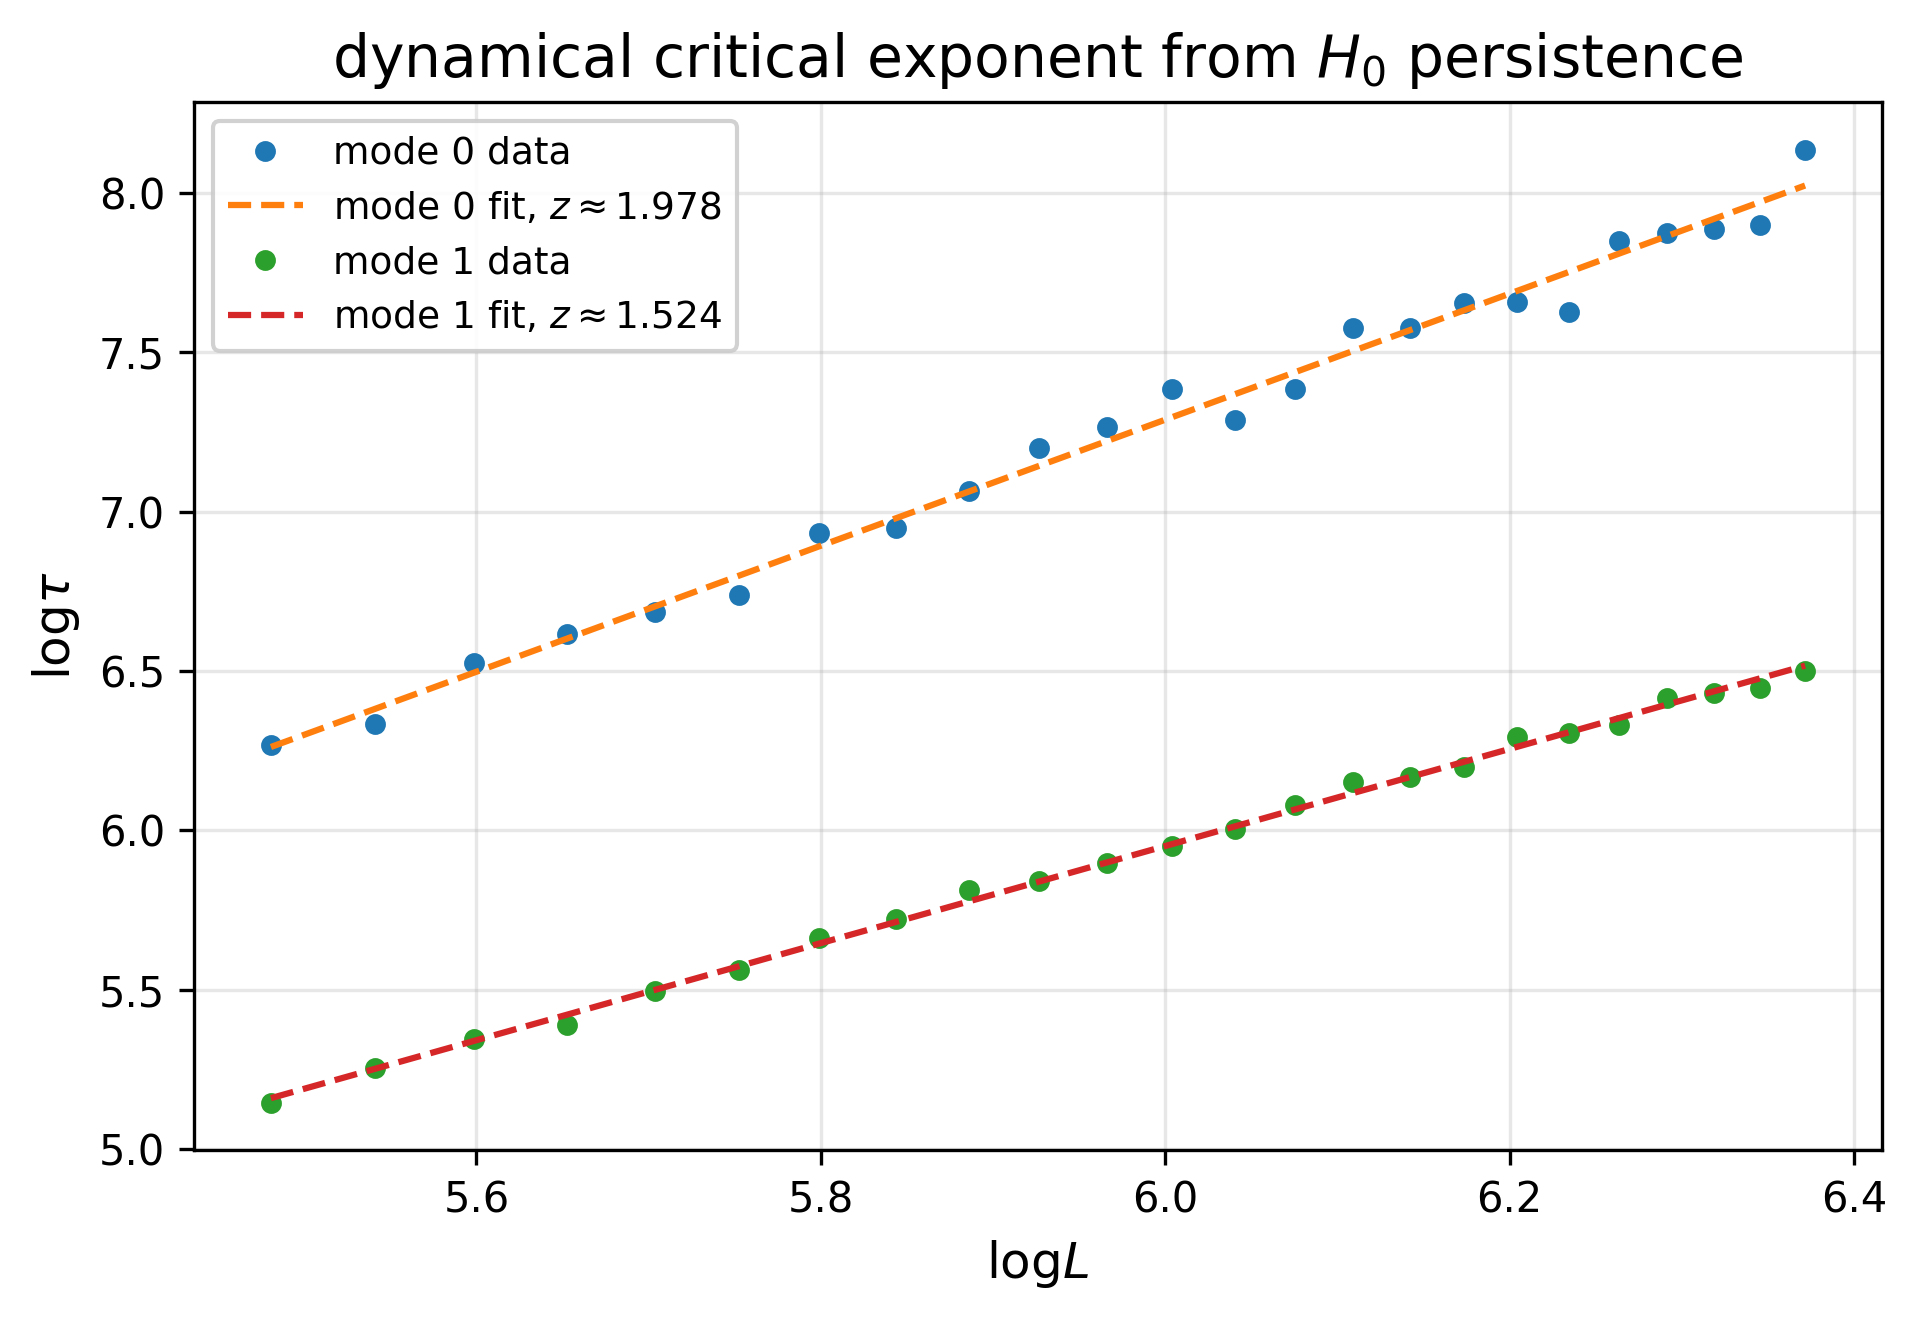

In [12]:
taus = np.array(taus)

plt.figure(figsize=(6.5, 4.5), dpi=300)

for mode_index in [0, 1]:
    taus_mode = taus[:, mode_index]

    valid = np.isfinite(taus_mode) & (taus_mode > 0)

    logL = np.log(L_values[valid])
    logtau = np.log(taus_mode[valid])

    z, intercept = np.polyfit(logL, logtau, 1)
    fit = intercept + z * logL

    plt.plot(logL, logtau, "o", markersize=4, label=fr"mode {mode_index} data")
    plt.plot(logL, fit, "--", linewidth=1.5, label=fr"mode {mode_index} fit, $z \approx {z:.3f}$")

    print(f"mode {mode_index}: z_TDA = {z}")

plt.xlabel(r"$\log L$", fontsize=12)
plt.ylabel(r"$\log\tau$", fontsize=12)
plt.title(r"dynamical critical exponent from $H_0$ persistence", fontsize=14)

plt.legend(fontsize=9, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Shutting Down Engines and Slurm Process

This shuts down the IPyParallel controller/engines

In [13]:
rc = ipp.Client(profile="default")

print("Engines before shutdown:", rc.ids)

rc.shutdown(hub=True)

print("Sent shutdown signal to IPyParallel engines and controller.")

Engines before shutdown: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Sent shutdown signal to IPyParallel engines and controller.


Exception in callback BaseAsyncIOLoop._handle_events(122, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(122, 1)>
Traceback (most recent call last):
  File "/usr/lib64/python3.6/asyncio/events.py", line 145, in _run
    self._callback(*self._args)
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib64/python3.6/site-packages/tornado/platform/asyncio.py", line 189, in _handle_events
    handler_func(fileobj, events)
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib64/python3.6/site-packages/zmq/eventloop/zmqstream.py", line 643, in _handle_events
    self._rebuild_io_state()
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib64/python3.6/site-packages/zmq/eventloop/zmqstream.py", line 698, in _rebuild_io_state
    self._update_handler(state)
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib64/python3.6/site-packages/zmq/eventloop/zmqstream.py", line 715, in _update_handler
    if state & self.socket.events:
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib64/python3.6/site-

The following confirms if the processes are shut down.

In [14]:
cmd = "ps -u $USER -f | grep -E 'ipcontroller|ipengine|ipcluster' | grep -v grep"
result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

print(result.stdout if result.stdout else "No IPyParallel processes found.")

No IPyParallel processes found.


This shuts down the the Slurm allocation/job

In [15]:
result = subprocess.run("scancel --name=ipengines_tda", shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

if (result.stdout != ""):
    print("STDOUT:", result.stdout)
    
if (result.stderr != ""):
    print("STDERR:", result.stderr)
    
print("Return code:", result.returncode)

Return code: 0
